# Counterfactual Guided by Prototypes(CFP)

설명 변수 $x$의 label을 다른 label을 가진 counterfactual을 생성하고자 할 때, 바람직한 counterfactual $x^{'}$ 의 조건을 정리하면 다음과 같다.

1. $x^{'}$에 대응하는 예측범주는 원하는 예측범주에 가까워야 한다. 여기에서 가깝다는 의미는 예측범주 확률이 높다는 의미이다.
1. 원래 설명 변수 $x$에 대해 counterfactual은 $x^{'} = x + \delta$ 로 정의되며, perturbation $\delta$ 는 sparse 해야 한다. Sparse는 $|\delta| \approx 0$을 의미한다.
1. $x^{'}$ 는 해석 가능해야 한다. $x^{'}$ 이 전테 데이터 분포 및 $x^{'}$ 이 소속된 범주의 데이터 분포와도 근접해야 한다는 의미이다.
1. $x^{'}$ 을 생성하는데 시간이 오래 걸리지 않아야 한다.

## CFP의 이론적 배경

앞서 논의한 조건을 충족시키기 위해 12장의 CEM은 autoencoder 손실함수를 도입했다. 그러나 autoencoder 손실 항은 전체 데이터의 분포를 유지하는 데 기여하지만, counterfactual이 소속된 label의 데이터 분포를 유지하는데 취약점을 가지고 있다.

CFP는 3번 조건을 만족시키기 위해 다음과 같이 손실함수에 $\theta L_2(x^{'}, x_{proto})$ 항을 정의한다. CEM의 손실함수와 유사한 형태이다.

$$
L(x^{'} | x) = c (f(x^{'}) - y^{'})^2 + \beta L_1 (x, x^{'}) + L_2(x, x^{'}) + \gamma L_2 (x^{'}, AE(x^{'})) + \theta L_2(x^{'}, x_{proto})
$$

$x_{proto}$ 는 $x^{'}$ 의 예측 label에서 $x^{'}$ 과 가장 가까운 $k$ 개의 표본들의 평균으로 정의된 설명 변수이다. 그러므로, $\theta L_2(x^{'}, x_{proto})$ 는 $x^{'}$ 이 속한 label의 데이터 분포와 counterfactual $x^{'}$ 의 분포가 최대한 가깝도록 조정하는 손실로 해석할 수 있다.

그러나 text 데이터나 image 데이터와 같이 설명 변수가 매우 크면 $x_{proto}$ 를 구하는 데 게산 부담이 지나치게 커지게 된다. 이를 해결하기 위해 autoencoder의 encoder로 데이터를 차원 축소한 후, 축소된 $x^{'}$ 의 KNN의 평균으로 차원 축소된 $x_{proto}$ 를 구한다. 이후 decoder를 이용하여 원래 차원으로 환원하여 $L_2(x^{'}, x_{proto})$를 계산한다.

차원 축소를 했더라도 데이터 크기가 크면 KNN을 구하는데 시간 부담이 있게 된다. 이러한 이유로 CFP는 4번 조건을 만족시키기 위해 k-d tree를 이용하여 $x^{'}$ 의 KNN을 구하기도 한다.

---

## k-d tree와 신뢰점수

### k-d tree

k-d tree는 설명변수를 차례대로 번갈아 가면서 자료를 반복적으로 이등분하여 구축한다.

설명변수가 2개 존재하는 2차원 자료 $(x, y)$를 이용하여 k-d tree를 구축하는 과정을 설명한다.



데이터 (15, 70), (40, 45), (66, 85), (69, 50), (70, 10), (85, 90)을 이용하여 k-d tree를 구축하면 아래의 그림과 같이 구성된다.

<div style="text-align: center;">
  <img src="https://opendsa-server.cs.vt.edu/ODSA/Books/CS3/html/_images/KDtree.png" alt="이미지 설명" />
  <p style="font-size: 12px; color: grey; text-align: center;">
    <em>
        <a href="https://opendsa-server.cs.vt.edu/ODSA/Books/CS3/html/KDtree.html">
            출처: CS3 Data Structures & Algorithms
        </a>
    </em>
  </p>
</div>

### 신뢰점수(Trust score)

k-d tree의 KNN을 이용하여 예측치의 신뢰도를 측정할 수 있다. 머신러닝 모델에서 특정 시험데이터를 입력하여 예측된 label 확률이 얼마나 신뢰할 수 있는가에 대한 측정 도구가 신뢰점수이다.

원본 데이터를 입력하여 예측된 label을 label1, counterfactual을 입력하여 예측된 label을 label2라고 가정하자. label1에 속하는 데이터와 label2에 속하는 데이터로 각각 k-d tree를 구성한다. 각 k-d tree에 대하여 counterfactual에 대한 KNN을 구해 평균을 구한 후, 이 평균을 각각 counterfactual과 label1, counterfactual과 label2의 거리로 정의한다. 그러면 counterfactual의 예측된 label 확률에 대한 신뢰점수는 다음과 같이 정의된다.

$$
TS(cf) = \frac{\text{label1의 거리}}{\text{label2의 거리}}
$$


위 신뢰점수는 높을수록 counterfactual의 label과 원래 데이터의 label이 멀리 떨어져 있다는 의미이므로 신뢰도가 높다고 말한다. 신뢰점수가 1이면 label1에서의 counterfactual의 거리와 label2에서의 거리가 같으므로 conterfactual의 label 변경의 신뢰도가 낮다고 할 수 있다.

---

## CFP의 적용과 응용

ALIBI에서 CFP의 적용은 CFI와 구조적으로 동일하다. CFP는 다음과 같이 동기화하고 필요한 옵션을 지정하면 된다.

```python
cf = CounterfactualProto(model, shape, kappa=0.0, beta=0.1, gamma=100.0, theta=100.0, ae_model=ae, max_iterations=500, c_init=1.0, c_steps=5)
```

여기서 `model`은 ALIBI 관점에서 유리박스 예측모델을, `shape`는 batch 크기가 1인 시험데이터의 shape를 지정한다. ALIBI 관점에서 유리박스 예측모델의 의미는 딥러닝 모델도 Tensorflow의 자동미분 기능 때문에 유리박스 모델에 해당된다는 의미이다.

$x_{proto}$를 구하기 위해 미리 학습된 autoencoder 모델의 encoder 출력이 필요하므로 학습데이터에 대한 `.fit` step이 필요하다.

이후 `.explain`을 적용하여 X의 counterfactual을 구한다.

```python
cf.explain(X, target_class=None, k=20, k_type='mean', verbose=True)
```

여기서 `target_class`에는 counterfactual의 목표 label을 지정할 수 있다.<br>
`k`는 KNN의 K를 의미하고, None이 기본값이며 None인 경우 $x_{proto}$는 학습데이터로부터 각 범주별 설명 변수의 평균으로 정의된다.<br>
`k_type`은 $x_{proto}$를 KNN의 mean으로 구하고자 할 때 주는 옵션이다. `'point'`로 설정하면 k번째 nearest neighbor로 $x_{proto}$를 구하게 된다.

$x_{proto}$를 구하기 위한 autoencoder가 없는 경우, 다음과 같이 k-d tree를 이용하여 구할 수 있다.
```python
cf = CounterfactualProto(model, shape, use_kdtree=True)
```

---

### Tabular 데이터

#### California housing

In [2]:
import tensorflow as tf
tf.compat.v1.disable_v2_behavior()
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical

import os
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from alibi.explainers import CounterfactualProto

import matplotlib.pyplot as plt

Counterfactual을 적용하기 편리하도록 데이터를 전처리한다.

In [3]:
california = fetch_california_housing(as_frame=True)
X = california.data.to_numpy()
target = california.target.to_numpy()
feature_names = california.feature_names
california.data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


목적 변수는 실수형인 주택가격이지만 counterfactual을 구하기 위해 task를 분류로 변경한다. 즉, 주택가격이 중위수보다 크면 1, 작으면 0으로 변경한다.

In [4]:
y = np.zeros(shape=(target.shape[0], ))
y[np.where(target > np.median(target))[0]] = 1

설명 변수에 대하여 표준화를 적용하고, 학습 및 시험데이터로 분리한다. 목적 변수를 one-hot encoding한다.

In [5]:
mu = X.mean(axis=0)
sigma = X.std(axis=0)
X = (X - mu) / sigma
X_train, X_test, y_trian, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = to_categorical(y_trian)
y_test = to_categorical(y_test)

딥러닝 모델을 정의하고 California Housing 데이터에 대해 학습 후 저장한다.

In [16]:
def nn_model():
    x_in = Input(shape=(8, ))
    x = Dense(40, activation='relu')(x_in)
    x = Dense(40, activation='relu')(x)
    x_out = Dense(2, activation='softmax')(x)
    nn = Model(inputs=x_in, outputs=x_out, name='NN')
    nn.compile(
        loss='categorical_crossentropy',
        optimizer='sgd',
        metrics=['accuracy']
    )
    return nn

In [19]:
nn = nn_model()
nn.summary()
nn.fit(X_train, y_train, batch_size=64, epochs=30, verbose=1)

Model: "NN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_8 (InputLayer)        [(None, 8)]               0         
                                                                 
 dense_17 (Dense)            (None, 40)                360       
                                                                 
 dense_18 (Dense)            (None, 40)                1640      
                                                                 
 dense_19 (Dense)            (None, 2)                 82        
                                                                 
Total params: 2082 (8.13 KB)
Trainable params: 2082 (8.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Train on 16512 samples
Epoch 1/30
 1024/16512 [>.............................] - ETA: 2s - loss: 0.6780 - acc: 0.6104

2025-03-13 19:37:29.650142: W tensorflow/c/c_api.cc:305] Operation '{name:'total_2/Assign' id:779 op device:{requested: '', assigned: ''} def:{{{node total_2/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](total_2, total_2/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


16512/16512 [==============================] - 1s 62us/sample - loss: 0.5873 - acc: 0.7448
Epoch 2/30
16512/16512 [==============================] - 1s 49us/sample - loss: 0.4772 - acc: 0.7852
Epoch 3/30
16512/16512 [==============================] - 1s 50us/sample - loss: 0.4348 - acc: 0.7940
Epoch 4/30
16512/16512 [==============================] - 1s 51us/sample - loss: 0.4119 - acc: 0.8055
Epoch 5/30
16512/16512 [==============================] - 1s 57us/sample - loss: 0.3958 - acc: 0.8167
Epoch 6/30
16512/16512 [==============================] - 1s 50us/sample - loss: 0.3848 - acc: 0.8235
Epoch 7/30
16512/16512 [==============================] - 1s 50us/sample - loss: 0.3775 - acc: 0.8281
Epoch 8/30
16512/16512 [==============================] - 1s 52us/sample - loss: 0.3721 - acc: 0.8304
Epoch 9/30
16512/16512 [==============================] - 1s 57us/sample - loss: 0.3681 - acc: 0.8333
Epoch 10/30
16512/16512 [==============================] - 1s 51us/sample - loss: 0.3643 - ac

In [ ]:
nn.save('nn_california.h5', save_format='h5')
nn = load_model('nn_california.h5')

In [26]:
score = nn.evaluate(X_test, y_test, verbose=0)
print('Test Accuracy:', score[1])

Test Accuracy: 0.85465115


CFP를 구하기 위한 표본 X_test[1]의 shape을 조정한 후, 변수명 `X_sample`로 지정한다.

In [27]:
X_sample = X_test[1].reshape((1, ) + X_test[1].shape)
shape = X_sample.shape

다음과 같이 CFP를 동기화한 후, `use_kdtree=True`로 지정하여 k-d tree로 $x_{proto}$를 구하도록 하고 있다.

In [29]:
cf = CounterfactualProto(nn, shape, use_kdtree=True, theta=10.0, max_iterations=1000, feature_range=(X_train.min(axis=0), X_train.max(axis=0)), c_init=1.0, c_steps=10)
cf.fit(X_train)

No encoder specified. Using k-d trees to represent class prototypes.


CounterfactualProto(meta={
  'name': 'CounterfactualProto',
  'type': ['blackbox', 'tensorflow', 'keras'],
  'explanations': ['local'],
  'params': {
              'kappa': 0.0,
              'beta': 0.1,
              'gamma': 0.0,
              'theta': 10.0,
              'cat_vars': None,
              'ohe': False,
              'use_kdtree': True,
              'learning_rate_init': 0.01,
              'max_iterations': 1000,
              'c_init': 1.0,
              'c_steps': 10,
              'eps': (0.001, 0.001),
              'clip': (-1000.0, 1000.0),
              'update_num_grad': 1,
              'write_dir': None,
              'feature_range': (array([-1.77429947, -2.19618048, -1.83504572, -1.61076772, -1.25612255,
       -0.22899997, -1.44288613, -2.38599234]), array([  5.85828581,   1.85618152,  55.16323628,  51.78248741,
        30.25033022, 119.41910319,   2.95806762,   2.62528006])),
              'shape': (1, 8),
              'is_model': True,
              '

표본의 CFP를 구한 후 확인한 `.data`의 구조는 다음과 같이 CFI와 거의 동일한 것을 알 수 있다.

In [30]:
explanation = cf.explain(X_sample)
print(explanation.data.keys())

dict_keys(['cf', 'all', 'orig_class', 'orig_proba', 'id_proto'])


아래에서 확인할 수 있듯이 표본의 label 0에서 CFP의 label 1로 변경된 것을 확인할 수 있다.

In [32]:
print(f"Original prediction: {explanation.orig_class}")
print(f"Counterfactual prediction: {explanation.cf['class']}")

Original prediction: 0
Counterfactual prediction: 1


다음은 원본 표본과 CFP와의 차이를 살며보기 위해 표준화된 설명 변수를 원래대로 환원한 후, 그 차이를 보여주고 있다.

설명 변수 longitude의 차이가 음의 값이므로 집의 위치가 남쪽으로 약간 이동되면 주택가격이 중위수 이하에서 중위수 이상으로 바뀌게 된다는 사실을 보여주고 있다.

In [33]:
origin = X_sample * sigma + mu
counterfactual = explanation.cf['X'] * sigma + mu
delta = counterfactual - origin
print(delta)

for i, f in enumerate(feature_names):
    if np.abs(delta[0][i]) > 1e-2:
        print(f"{f}: {delta[0][i]}")

[[ 1.94352855e-03  3.79467160e-08 -1.79144086e-08  2.23376229e-09
   3.66006270e-06 -7.58506762e-01 -2.62142244e-02 -8.62419316e-02]]
AveOccup: -0.7585067616929972
Latitude: -0.026214224393072527
Longitude: -0.08624193164344263


다음은 표본과 CFP의 설명 변수값을 구체적으로 보여주고 있다.

In [37]:
pd.DataFrame(origin, columns=feature_names)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46


In [38]:
pd.DataFrame(counterfactual, columns=feature_names)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.533244,30.0,5.039384,1.193493,1565.000004,1.921288,35.113786,-119.546242


---

#### Adult

CFP를 tabular 데이터에 적용할 때 범주형 설명 변수를 포함하고 있다면, 범주형 자료를 one-hot encoding해야 할 뿐만 아니라 범주형 설명 변수를 index화하고 범주값을 포함하는 dictionary 자료를 만들어야 한다. 또한, $x_{proto}$를 구하기 위해 범주형 설명 변수 간의 거리를 측정하는 방법도 정의해야 한다. 이와 같이 범주형 설명 변수를 가지고 있는 tabular 데이터는 설명 가능한 counterfactual을 구하기 위한 전처리과정이 지루할 정도로 복잡하다. 이러한 이유로 실수형 및 범주형 설명 변수를 가지고 있는 tabular 데이터에서 설명 가능한 CFP를 구하기 위한 전처리과정을 구체적으로 살펴본다.

In [42]:
import tensorflow as tf
tf.get_logger().setLevel(40)
tf.compat.v1.disable_v2_behavior()
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

import os
from time import time
from pprint import pprint
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from alibi.datasets import fetch_adult
from alibi.explainers import CounterfactualProto
from alibi.utils import ohe_to_ord, ord_to_ohe

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

Adult 데이터를 살며보면, category_map_tmp의 출력에서 볼 수 있듯이 1 ~ 7번 째, 11번 째 열이 범주형 설명 변수임을 보여주고 있고, 이 열 번호가 key로 되어 있다.

`fetch_adult().data`를 출력해 보면 text로 표현된 범주형 설명 변수의 범주값을 순서형 정수(ordinary integer)로 미리 변경해 놓은 것을 확인할 수 있다.

In [43]:
adult = fetch_adult()
data = adult.data
print(data[:2])

target = adult.target
feature_names = adult.feature_names
category_map_tmp = adult.category_map
pprint(category_map_tmp)
target_names = adult.target_names

[[  39    7    1    1    1    1    4    1 2174    0   40    9]
 [  50    6    1    0    8    0    4    1    0    0   13    9]]
{1: ['?',
     'Federal-gov',
     'Local-gov',
     'Never-worked',
     'Private',
     'Self-emp-inc',
     'Self-emp-not-inc',
     'State-gov',
     'Without-pay'],
 2: ['Associates',
     'Bachelors',
     'Doctorate',
     'Dropout',
     'High School grad',
     'Masters',
     'Prof-School'],
 3: ['Married', 'Never-Married', 'Separated', 'Widowed'],
 4: ['?',
     'Admin',
     'Blue-Collar',
     'Military',
     'Other',
     'Professional',
     'Sales',
     'Service',
     'White-Collar'],
 5: ['Husband',
     'Not-in-family',
     'Other-relative',
     'Own-child',
     'Unmarried',
     'Wife'],
 6: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White'],
 7: ['Female', 'Male'],
 11: ['?',
      'British-Commonwealth',
      'China',
      'Euro_1',
      'Euro_2',
      'Latin-America',
      'Other',
      'SE-Asia',
      'So

설명 변수 data와 목적 변수 target을 `np.c_[data, target]`으로 표본 id 순으로 옆으로 붙인 후, 학습데이터와 시험데이터가 동일한 분포를 갖도록 하기 위해 permutation 함수를 이용하여 데이터를 shuffling하고 있다.

이 후 첫 30,000개의 데이터를 학습데이터로 나머지는 시험데이터로 정의한다.

In [ ]:
data_perm = np.random.permutation(np.c_[data, target])
X = data_perm[:, :-1]
y = data_perm[:, -1]

idx = 30000
y_train, y_test = y[:idx], y[idx:]

범주형 설명 변수를 앞에 위치하고, 실수형 설명 변수가 뒤따르도록 설명 변수의 순서를 조정한다. 전처리과정을 편리하게 하기 위함이다.

이 순서에 따라 설명 변수명 과 category_map의 순서도 변경한다.

In [ ]:
X = np.c_[X[:, 1:8], X[:, 11], X[:, 0], X[:, 8:11]]

feature_names = feature_names[1:8] + feature_names[11:12] + feature_names[0:1] + feature_names[8:11]

category_map = {}
for i, (_, v) in enumerate(category_map_tmp.items()):
    category_map[i] = v
print(category_map.keys())

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])


구성된 데이터의 범주값 수준을 나타내는 `cat_vars_ord`변수를 정의한다.

In [50]:
cat_vars_ord = {}
n_categories = len(category_map.keys())

for i in range(n_categories):
    cat_vars_ord[i] = len(np.unique(X[:,i]))
print(cat_vars_ord)

{0: 9, 1: 7, 2: 4, 3: 9, 4: 6, 5: 5, 6: 2, 7: 11}


다음은 alibi의 utility 함수인 `ord_to_ohe`를 적용한 결과를 보여주고 있다.

앞에서 확인한 순서형 정수로 정의된 범주형 설명 변수를 one-hot encoding하고 있다.

ord_to_ohe[0]은 one-hot encoding된 자료를 제공하고, ord_to_ohe[1]은 dictionary 데이터로 one-hot encoding된 각 설명 변수의 시작 column을 key로 하고 value는 범주값 수로 정의하고 있다.

예를 들어, 첫 번째 범주형 설명 변수는 0 column에서 시작하고 범주값이 9이므로 두 번째 범주형 설명 변수의 시작 column은 9이고 범주값 수 는 7이다. 세 번째 범주형 설명 변수의 시작 column은 9 + 7 = 16이며 범주값은 4인 것을 확인할 수 있다.

In [52]:
print(ord_to_ohe(X, cat_vars_ord)[0][:2])
cat_vars_ohe = ord_to_ohe(X, cat_vars_ord)[1]
print(cat_vars_ohe)

[[ 0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  1.  0.
   0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0. 43.
   0.  0. 84.]
 [ 0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.  1.
   0.  0.  0.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.  0.
   0.  0.  0.  1.  0.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0. 27.
   0.  0. 60.]]
{0: 9, 9: 7, 16: 4, 20: 9, 29: 6, 35: 5, 40: 2, 42: 11}


실수형 설명 변수의 값이 -1 ~ 1이 되도록 표준화한다.

In [ ]:
X_num = X[:, -4:].astype(np.float32, copy=False)
xmin, xmax = X_num.min(axis=0), X_num.max(axis=0)
rng = (-1.0, 1.0)
X_num_scaled = (X_num - xmin) / (xmax - xmin) * (rng[1] - rng[0]) + rng[0]
print(X_num_scaled.min(axis=0))
print(X_num_scaled.max(axis=0))

[-1. -1. -1. -1.]
[1. 1. 1. 1.]


sklearn의 `OneHotEncoder`를 이용하여 one-hot encoding하여 이를 `x_cat_ohe`로 정의하고 있다.

In [57]:
X_cat = X[:, :-4].copy()
ohe = OneHotEncoder(categories='auto', sparse_output=False).fit(X_cat)
X_cat_ohe = ohe.transform(X_cat)
print(X_cat_ohe[:2])

[[0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0.
  0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 1. 0.]]


전처리한 실수형 및 범주형 설명 변수를 옆으로 이어붙인 후 목적 변수에 대응되도록 학습 및 시험데이터로 분리한다.

In [ ]:
X = np.c_[X_cat_ohe, X_num_scaled].astype(np.float32, copy=False)
X_train, X_test = X[:idx], X[idx:]
print(X_train.shape)
print(X_test.shape)

(30000, 57)
(2561, 57)


앞서 정의한 학습데이터를 딥러닝 모델에 적용하여 수입이 50K 이상인지(1), 미만인지(0)를 예측하기 위해 다음과 같이 `fwd()` 함수를 정의하고 학습시킨다.

In [64]:
def fwd():
    x_in = Input(shape=(57, ))
    x = Dense(60, activation='relu')(x_in)
    x = Dropout(0.2)(x)
    x = Dense(60, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(60, activation='relu')(x)
    x = Dropout(0.2)(x)
    x_out = Dense(2, activation='softmax')(x)

    nn = Model(inputs=x_in, outputs=x_out)
    nn.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return nn

In [65]:
nn = fwd()
nn.summary()
nn.fit(X_train, to_categorical(y_train), batch_size=256, epochs=30, verbose=0)

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_11 (InputLayer)       [(None, 57)]              0         
                                                                 
 dense_22 (Dense)            (None, 60)                3480      
                                                                 
 dropout_2 (Dropout)         (None, 60)                0         
                                                                 
 dense_23 (Dense)            (None, 60)                3660      
                                                                 
 dropout_3 (Dropout)         (None, 60)                0         
                                                                 
 dense_24 (Dense)            (None, 60)                3660      
                                                                 
 dropout_4 (Dropout)         (None, 60)                0     

2025-03-13 20:34:32.260390: W tensorflow/c/c_api.cc:305] Operation '{name:'training_8/Adam/dense_23/kernel/v/Assign' id:2899 op device:{requested: '', assigned: ''} def:{{{node training_8/Adam/dense_23/kernel/v/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](training_8/Adam/dense_23/kernel/v, training_8/Adam/dense_23/kernel/v/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


CFP를 구하기 위한 표본 X_test[0]를 reshape한 후, `X_sample`로 저장한다.

In [66]:
X_sample = X_test[0].reshape((1, ) + X_test[0].shape)

CFP를 동기화하기 위한 입력 옵션을 정의한다.

In [67]:
rng = (-1, 1)
rng_shape = (1, ) + data.shape[1:]
cfp_config = {
    'shape': X_sample.shape,
    'beta': 0.01,
    'c_init': 1.0,
    'c_steps': 5,
    'max_iterations': 500,
    'feature_range': ((np.ones(shape=rng_shape) * rng[0]).astype(np.float32),
                      (np.ones(shape=rng_shape) * rng[1]).astype(np.float32))
}

다음과 같이 CFP를 동기화하고, 앞서 정의한 `cat_vars_ohe`를 `cat_vars`에 지정하고 범주형 설명 변수를 one_hot encoding했으므로 `ohe=True`로 지정한다.

In [69]:
cf = CounterfactualProto(nn, cat_vars=cat_vars_ohe, ohe=True, **cfp_config)

손실함수에서 범주형 설명 변수의 거리를 측정하는 방법으로 `d_type='abdm'`으로 지정하고 있다. `'abdm'`이 기본값이다.

실수형 설명 변수의 거리도 `'abdm'`으로 측정하기 위해 `disc_perc`를 이용하여 25%, 50%, 75% 분위수로 구간화한다. `[25, 50, 75]`가 기본값이다.


In [ ]:
cf.fit(X_train, d_type='abdm', disc_perc=[25, 50, 75])

다음과 같이 표본의 CFP를 구하고, `.data.keys()`와 `.data['cf'].keys()`를 출력한다.

In [ ]:
explanation = cf.explain(X_sample)
print(explanation.data.keys())
print(explanation.data['cf'].keys())

dict_keys(['cf', 'all', 'orig_class', 'orig_proba', 'id_proto'])
dict_keys(['X', 'class', 'proba', 'grads_graph', 'grads_num'])


아래의 `describe_instance()` 함수는 `.data.keys()`의 'original_class'와 'orig_proba'로 표본의 예측 label과 label에 속할 확률을 출력하고, `.data['cf'].keys()`의 'class'와 'proba'로 CFP의 예측 label과 label에 속할 확률을 출력하는 함수이다.

또한, `ohe_to_ord()`를 이용하여 표본과 CFP를 원래 데이터 형식으로 환원한 후, 표본과 CFP의 차이를 범주형 설명변수와 실수형 설명변수로 나누어 출력하고 있다.<br>
이 때, 범주가 변경된 경우 `A-->B`의 형태로 출력하고, 실수형 설명변수의 경우 $10^{-2}$보다 차이 가 클 경우만 출력하고 있다.

In [74]:
def describe_instance(X, explanation, eps=1e-2):
    print(f"Original instance: {target_names[explanation.orig_class]}  -- proba: {explanation.orig_proba[0]}")
    print(f"Counterfactual instance: {target_names[explanation.cf['class']]}  -- proba: {explanation.cf['proba'][0]}")
    print('\nCounterfactual perturbations...')
    print('\nCategorical:')
    X_orig_ord = X
    X_cf_ord = explanation.cf['X']
    delta_cat = {}
    for i, (_, v) in enumerate(category_map.items()):
        cat_orig = v[int(X_orig_ord[0, i])]
        cat_cf = v[int(X_cf_ord[0, i])]
        if cat_orig != cat_cf:
            delta_cat[feature_names[i]] = [cat_orig, cat_cf]
    if delta_cat:
        for k, v in delta_cat.items():
            print('{}: {}  -->   {}'.format(k, v[0], v[1]))
    print('\nNumerical:')
    delta_num = X_cf_ord[0, -4:] - X_orig_ord[0, -4:]
    n_keys = len(list(cat_vars_ord.keys()))
    for i in range(delta_num.shape[0]):
        if np.abs(delta_num[i]) > eps:
            print(f'{feature_names[i+n_keys]}: {X_orig_ord[0,i+n_keys]:.2f}  -->   {X_cf_ord[0,i+n_keys]:.2f}')

In [75]:
describe_instance(X_sample, explanation)

Original instance: <=50K  -- proba: [9.9982184e-01 1.7812906e-04]
Counterfactual instance: >50K  -- proba: [0.22737102 0.77262896]

Counterfactual perturbations...

Categorical:

Numerical:
Capital Gain: 0.00  -->   0.00


지금까지 `x_proto`를 적용하지 않았기 때문에, $x_{proto}$의 손실함수 가중치는 기본값, $\theta = 0$으로 지정되었다.

아래는 k-d tree를 이용하여 `x_proto`를 구하고 이에 대한 손실함수를 정의하기 위해 `use_kdtree=True`로 지정하고, `theta=10.0`으로 지정한다.

In [77]:
cfp_config['use_kdtree'] = True
cfp_config['theta'] = 10.0
cfp_config['cat_vars'] = cat_vars_ohe
cfp_config['ohe'] = True

X_test[7]를 표본으로 선정하고 `describe_instance()`함수를 적용한다.

In [ ]:
X_sample = X_test[7].reshape((1, ) + X_test[7].shape)
cf = CounterfactualProto(nn, **cfp_config)
cf.fit(X_train, d_type='abdm')

In [81]:
explanation = cf.explain(X_sample)
describe_instance(X_sample, explanation)

Original instance: <=50K  -- proba: [0.9817535  0.01824643]
Counterfactual instance: >50K  -- proba: [0.08015564 0.9198443 ]

Counterfactual perturbations...

Categorical:

Numerical:
Capital Gain: 1.00  -->   0.00
Hours per week: 0.00  -->   0.00


이제 autoencoder를 추가하여 x_proto가 예측 label의 데이터분포를 벗어나지 않도록 하는 autoencoder 손실함수를 추가하고, autoencoder의 encoder를 이용하여 x_proto를 구하기 위해 autoencoder 모델을 학습시킨다.

In [82]:
def ae_model():
    # encoder
    x_in = Input(shape=(57, ))
    x = Dense(60, activation='relu')(x_in)
    x = Dense(30, activation='relu')(x)
    x = Dense(15, activation='relu')(x)
    encoded = Dense(10, activation=None)(x)
    encoder = Model(inputs=x_in, outputs=encoded, name='Encoder')

    # decoder
    dec_in = Input(shape=(10, ))
    x = Dense(15, activation='relu')(dec_in)
    x = Dense(30, activation='relu')(x)
    x = Dense(60, activation='relu')(x)
    decoded = Dense(57, activation=None)(x)
    decoder = Model(inputs=dec_in, outputs=decoded, name='Decoder')
    
    # autoencoder
    x_out = decoder(encoder(x_in))
    autoencoder = Model(inputs=x_in, outputs=x_out, name='AutoEncoder')
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder, decoder

In [86]:
ae, enc, dec = ae_model()
ae.summary()
ae.fit(X_train, X_train, batch_size=128, epochs=100, validation_data=(X_test, X_test), verbose=0)

Model: "AutoEncoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_18 (InputLayer)       [(None, 57)]              0         
                                                                 
 Encoder (Functional)        (None, 10)                5935      
                                                                 
 Decoder (Functional)        (None, 57)                5982      
                                                                 
Total params: 11917 (46.55 KB)
Trainable params: 11917 (46.55 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


2025-03-13 21:04:40.525695: W tensorflow/c/c_api.cc:305] Operation '{name:'dense_55/kernel/Assign' id:9750 op device:{requested: '', assigned: ''} def:{{{node dense_55/kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](dense_55/kernel, dense_55/kernel/Initializer/random_uniform)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-13 21:04:41.402826: W tensorflow/c/c_api.cc:305] Operation '{name:'loss_10/mul' id:9858 op device:{requested: '', assigned: ''} def:{{{node loss_10/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss_10/mul/x, loss_10/Decoder_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running t

다음과 같이 autoencoder 손실함수의 가중치를 추가한후 표본 X_test[9]의 CFP를 구한다.

In [91]:
cfp_config['beta'] = 0.1 # L1
cfp_config['gamma'] = 10.0 # autoencoder
cfp_config['theta'] = 0.1 # prototype
cfp_config['use_kdtree'] = False

In [ ]:
X_sample = X_test[9].reshape((1, ) + X_test[9].shape)
cf = CounterfactualProto(nn, **cfp_config)
cf.fit(X_train, d_type='abdm')

In [93]:
explanation = cf.explain(X_sample)
describe_instance(X_sample, explanation)

Original instance: <=50K  -- proba: [0.9591817  0.04081834]
Counterfactual instance: >50K  -- proba: [0.4838737 0.5161263]

Counterfactual perturbations...

Categorical:

Numerical:
Capital Gain: 0.00  -->   0.00


#### Embedding layer를 이용한 tabular 데이터의 분석

지금까지 범주형 설명 변수를 포함한 tabular 데이터로부터 CFP를 구하기 위해 범주형 설명 변수를 one-hot encoding하고 CounterfactualProto의 입력 옵션인 `cat_vars`를 alibi의 `ord_to_ohe()` 함수로 구하였다. 또한 `ohe_to_ord()` 함수를 이용하여 원래의 데이터 형태로 환원하여 CFP를 설명 가능하도록 하였다.

Tabular 데이터의 범주형 설명 변수는 NLP에서 필수적으로 사용하는 Embedding Layer를 이용하여 범주값의 특성을 반영하는 실수형 자료로 변환할 수 있다.

앞에서 사용한 데이터 adult 데이터에 Embedding Layer를 적용하여 범주형 설명 변수를 실수로 변환한 후, CFP를 구하는 과정을 살펴보자.

In [33]:
import tensorflow as tf
tf.get_logger().setLevel(40)
tf.compat.v1.disable_v2_behavior()
from tensorflow.keras.layers import Dense, Input, Embedding, Flatten, Concatenate, Reshape, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical

import os
from time import time
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import OneHotEncoder
from alibi.datasets import fetch_adult
from alibi.explainers import CounterfactualProto

데이터의 전처리 과정은 앞에서 적용한 것과 거의 동일하지만, ord_to_ohe와 범주형 설명 변수를 one-hot encoding으로 전환하는 과정이 없다는 차이점이 있다.

In [63]:
adult = fetch_adult()
data = adult.data

target = adult.target
feature_names = adult.feature_names
category_map_tmp = adult.category_map

target_names = adult.target_names
data_perm = np.random.permutation(np.c_[data, target])
X = data_perm[:, :-1]
y = data_perm[:, -1]

idx = 30000
y_train, y_test = y[:idx], y[idx:]

X = np.c_[X[:, 1:8], X[:, 11], X[:, 0], X[:, 8:11]]

feature_names = feature_names[1:8] + feature_names[11:12] + feature_names[0:1] + feature_names[8:11]

category_map = {}
for i, (_, v) in enumerate(category_map_tmp.items()):
    category_map[i] = v
    
print(category_map.keys())
cat_vars_ord = {}
n_categories = len(category_map.keys())

for i in range(n_categories):
    cat_vars_ord[i] = len(np.unique(X[:,i]))
print(cat_vars_ord)

X_num = X[:, -4:].astype(np.float32, copy=False)
xmin, xmax = X_num.min(axis=0), X_num.max(axis=0)
rng = (-1.0, 1.0)
X_num_scaled = (X_num - xmin) / (xmax - xmin) * (rng[1] - rng[0]) + rng[0]

X = np.c_[X[:, :-4].copy(), X_num_scaled].astype(np.float32, copy=False)
X_train, X_test = X[:idx], X[idx:]

print(X_train.shape)
print(X_test.shape)

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])
{0: 9, 1: 7, 2: 4, 3: 9, 4: 6, 5: 5, 6: 2, 7: 11}
(30000, 12)
(2561, 12)


순서형 정수로 정의된 범주형 설명 변수값을 Embedding Layer에 입력하여 실수형 데이터로 변환한 후, 딥러닝 모델을 정의하는 `nn_ord()` 함수를 정의한다.

In [64]:
def nn_ord():
    x_in = Input(shape=(12, ))
    layers_in = []
    # embedding layers
    for i , (_, v) in enumerate(cat_vars_ord.items()):
        emb_in = Lambda(lambda x: x[:, i:i + 1] + 1)(x_in)
        emb_dim = int(max(min(np.ceil(0.5 * v), 50), 2))
        emb_layer = Embedding(input_dim=v + 1, output_dim=emb_dim, input_length=1)(emb_in)
        emb_layer = Flatten()(emb_layer)
        layers_in.append(emb_layer)
    # numerical layers
    num_in = Lambda(lambda x: x[:, -4:])(x_in)
    num_layer = Dense(16)(num_in)
    layers_in.append(num_layer)
    # combine
    x = Concatenate()(layers_in)
    x = Dense(60, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(60, activation='relu')(x)
    x = Dropout(0.2)(x)
    x = Dense(60, activation='relu')(x)
    x = Dropout(0.2)(x)
    x_out = Dense(2, activation='softmax')(x)
    
    nn = Model(inputs=x_in, outputs=x_out, name='NN_Embedding')
    nn.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return nn

다음은 cat_vars_ord의 첫 key는 0이고 value는 9일 때, 3이 입력되면 Embedding layer에 의해 출력된 5개의 실수 벡터를 출력한다.

In [65]:
aa = int(max(min(np.ceil(0.5 * 9), 50), 2))

v = 9
model = tf.keras.Sequential()
model.add(Embedding(v + 1, aa, input_length=1))
model.compile('rmsprop', 'mse')
output_array = model.predict(np.array([3]))
print(output_array)

/home/ljh/anaconda3/envs/xai/lib/python3.9/site-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-03-14 16:30:38.639433: W tensorflow/c/c_api.cc:305] Operation '{name:'embedding_38/embeddings/Assign' id:7703 op device:{requested: '', assigned: ''} def:{{{node embedding_38/embeddings/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](embedding_38/embeddings, embedding_38/embeddings/Initializer/random_uniform)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


[[[-0.02779702  0.0086835   0.0460509   0.00443168  0.00039743]]]


In [66]:
nn = nn_ord()
nn.summary()

Model: "NN_Embedding"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 12)]                 0         []                            
                                                                                                  
 lambda_37 (Lambda)          (None, 1)                    0         ['input_6[0][0]']             
                                                                                                  
 lambda_38 (Lambda)          (None, 1)                    0         ['input_6[0][0]']             
                                                                                                  
 lambda_39 (Lambda)          (None, 1)                    0         ['input_6[0][0]']             
                                                                                       

다음과 같이 X_train과 one-hot encoding한 y_train으로 모델을 학습시킨다.

In [67]:
nn.fit(X_train, to_categorical(y_train), batch_size=128, epochs=30, verbose=1)

Train on 30000 samples
Epoch 1/30


2025-03-14 16:30:42.193650: W tensorflow/c/c_api.cc:305] Operation '{name:'embedding_40/embeddings/Assign' id:7767 op device:{requested: '', assigned: ''} def:{{{node embedding_40/embeddings/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](embedding_40/embeddings, embedding_40/embeddings/Initializer/random_uniform)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


30000/30000 [==============================] - 3s 86us/sample - loss: 0.4027 - acc: 0.8119
Epoch 2/30
30000/30000 [==============================] - 2s 81us/sample - loss: 0.3314 - acc: 0.8489
Epoch 3/30
30000/30000 [==============================] - 2s 81us/sample - loss: 0.3219 - acc: 0.8526
Epoch 4/30
30000/30000 [==============================] - 2s 81us/sample - loss: 0.3167 - acc: 0.8562
Epoch 5/30
30000/30000 [==============================] - 2s 80us/sample - loss: 0.3147 - acc: 0.8546
Epoch 6/30
30000/30000 [==============================] - 2s 81us/sample - loss: 0.3154 - acc: 0.8556
Epoch 7/30
30000/30000 [==============================] - 2s 82us/sample - loss: 0.3130 - acc: 0.8586
Epoch 8/30
30000/30000 [==============================] - 2s 80us/sample - loss: 0.3117 - acc: 0.8580
Epoch 9/30
30000/30000 [==============================] - 2s 80us/sample - loss: 0.3109 - acc: 0.8587
Epoch 10/30
30000/30000 [==============================] - 4s 127us/sample - loss: 0.3095 - a

In [68]:
score = nn.evaluate(X_test, to_categorical(y_test))
print(score)

/home/ljh/anaconda3/envs/xai/lib/python3.9/site-packages/keras/src/engine/training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates
2025-03-14 16:32:00.490909: W tensorflow/c/c_api.cc:305] Operation '{name:'loss_11/mul' id:8139 op device:{requested: '', assigned: ''} def:{{{node loss_11/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss_11/mul/x, loss_11/dense_24_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


[0.31733485657179183, 0.8457634]


CFP를 구하기 위한 표본을 X_test[0]으로 선정하고, 이 표본을 딥러닝 모델에 입력하기 위해 아래와 같이 4D 텐서로 reshape한다.

In [69]:
X_sample = X_test[0].reshape((1, ) + X_test[0].shape)

다음과 같이 CounterfactualProto의 입력 옵션을 정의하고, 딥러닝 모델 `nn`을 블랙박스 모델로 간주하여 예측함수를 정의한다.

In [79]:
rng = (-1.0, 1.0)
rng_shape = (1, ) + data.shape[1:]

cfp_config = {
    'shape': X_sample.shape,
    'beta': 0.01,
    'c_init': 1.0,
    'c_steps': 5,
    'max_iterations': 500,
    'feature_range': ((np.ones(shape=rng_shape) * rng[0]).astype(np.float32),
                      (np.ones(shape=rng_shape) * rng[1]).astype(np.float32)),
    'eps': (0.01, 0.01)
}

predict_fn = lambda x: nn.predict(x)

In [ ]:
cf = CounterfactualProto(predict_fn, cat_vars=cat_vars_ord, **cfp_config)
cf.fit(X_train, d_type='abdm', disc_perc=[25, 50, 75])
explanation = cf.explain(X_sample)

In [82]:
def describe_instance(X, explanation, eps=1e-2):
    print(f"Original instance: {target_names[explanation.orig_class]}  -- proba: {explanation.orig_proba[0]}")
    print(f"Counterfactual instance: {target_names[explanation.cf['class']]}  -- proba: {explanation.cf['proba'][0]}")
    print('\nCounterfactual perturbations...')
    print('\nCategorical:')
    X_orig_ord = X
    X_cf_ord = explanation.cf['X']
    delta_cat = {}
    for i, (_, v) in enumerate(category_map.items()):
        cat_orig = v[int(X_orig_ord[0, i])]
        cat_cf = v[int(X_cf_ord[0, i])]
        if cat_orig != cat_cf:
            delta_cat[feature_names[i]] = [cat_orig, cat_cf]
    if delta_cat:
        for k, v in delta_cat.items():
            print('{}: {}  -->   {}'.format(k, v[0], v[1]))
    print('\nNumerical:')
    delta_num = X_cf_ord[0, -4:] - X_orig_ord[0, -4:]
    n_keys = len(list(cat_vars_ord.keys()))
    for i in range(delta_num.shape[0]):
        if np.abs(delta_num[i]) > eps:
            print(f'{feature_names[i+n_keys]}: {X_orig_ord[0,i+n_keys]:.2f}  -->   {X_cf_ord[0,i+n_keys]:.2f}')

In [83]:
describe_instance(X_sample, explanation)

Original instance: <=50K  -- proba: [0.87250614 0.12749392]
Counterfactual instance: >50K  -- proba: [0.49688533 0.5031147 ]

Counterfactual perturbations...

Categorical:

Numerical:
Capital Gain: -1.00  -->   -0.92


---

### Image 데이터 - MNIST

In [84]:
import tensorflow as tf
tf.get_logger().setLevel(40)
tf.compat.v1.disable_v2_behavior()
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten, MaxPool2D, Input, UpSampling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.utils import to_categorical

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import os
from time import time
import numpy as np

from alibi.explainers import CounterfactualProto

다음과 같이 학습데이터와 시험데이터로 분리하고 이미지 2를 예시로 출력한다.

X_train shape: (60000, 28, 28)
y_train shape: (60000, 28, 28)


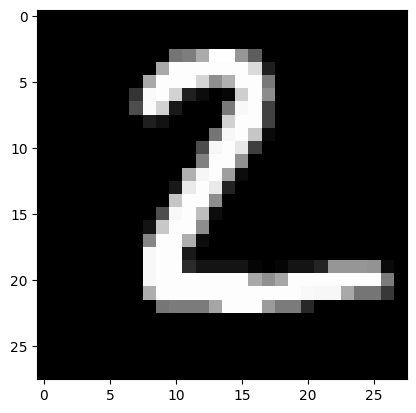

In [92]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print("X_train shape:", X_train.shape)
print("y_train shape:", X_train.shape)
plt.gray()
plt.imshow(X_test[1])

다음은 데이터의 전처리과정이다.

In [93]:
X_train = X_train.astype('float32') / 255
X_test = X_test.astype('float32') / 255
X_train = np.reshape(X_train, X_train.shape + (1,))
X_test = np.reshape(X_test, X_test.shape + (1,))
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (60000, 28, 28, 1)
X_test shape: (10000, 28, 28, 1)
y_train shape: (60000, 10)
y_test shape: (10000, 10)


In [94]:
xmin, xmax = -5, 5
X_train = ((X_train - X_train.min()) / (X_train.max() - X_train.min())) * (xmax - xmin) + xmin
X_test = ((X_test - X_test.min()) / (X_test.max() - X_test.min())) * (xmax - xmin) + xmin

다음과 같이 MNIST 데이터의 label을 예측하는 CNN 모델의 정의하고 학습시킨다.

In [95]:
x_in = Input(shape=(28, 28, 1))
x = Conv2D(filters=32, kernel_size=2, padding='same', activation='relu')(x_in)
x = MaxPool2D(pool_size=2)(x)
x = Dropout(0.3)(x)
x = Conv2D(filters=64, kernel_size=2, padding='same', activation='relu')(x)
x = MaxPool2D(pool_size=2)(x)
x = Dropout(0.3)(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x_out = Dense(10, activation='softmax')(x)

cnn = Model(inputs=x_in, outputs=x_out, name = 'CNN')
cnn.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
cnn.fit(X_train, y_train, batch_size=32, epochs=3, verbose=0)
cnn.save('mnist_cnn.h5', save_format='h5')

CFP를 구하기 위해 필요한 autoencoder 모델을 `ae_model()` 함수로 정의하고 다음과 같이 학습시킨다.

In [97]:
def ae_model():
    # encoder
    x_in = Input(shape=(28, 28, 1))
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x_in)
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    x = MaxPool2D((2, 2), padding='same')(x)
    encoded = Conv2D(1, (3, 3), activation=None, padding='same')(x)
    encoder = Model(x_in, encoded)

    # decoder
    dec_in = Input(shape=(14, 14, 1))
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(dec_in)
    x = UpSampling2D((2, 2))(x)
    x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    decoded = Conv2D(1, (3, 3), activation=None, padding='same')(x)
    decoder = Model(dec_in, decoded)

    # autoencoder
    x_out = decoder(encoder(x_in))
    autoencoder = Model(x_in, x_out)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder, decoder

In [ ]:
ae, enc, dec = ae_model()
ae.fit(X_train, X_train, batch_size=128, epochs=4, validation_data=(X_test, X_test))
ae.save('mnist_ae.h5', save_format='h5')
enc.save('mnist_enc.h5', save_format='h5')

다음은 학습된 모델을 불러와 autoencoder의 성능을 확인하고 있다.

In [ ]:
ae = load_model('mnist_ae.h5')
enc = load_model('mnist_enc.h5', compile=False)
decoded_imgs = ae.predict(X_test)

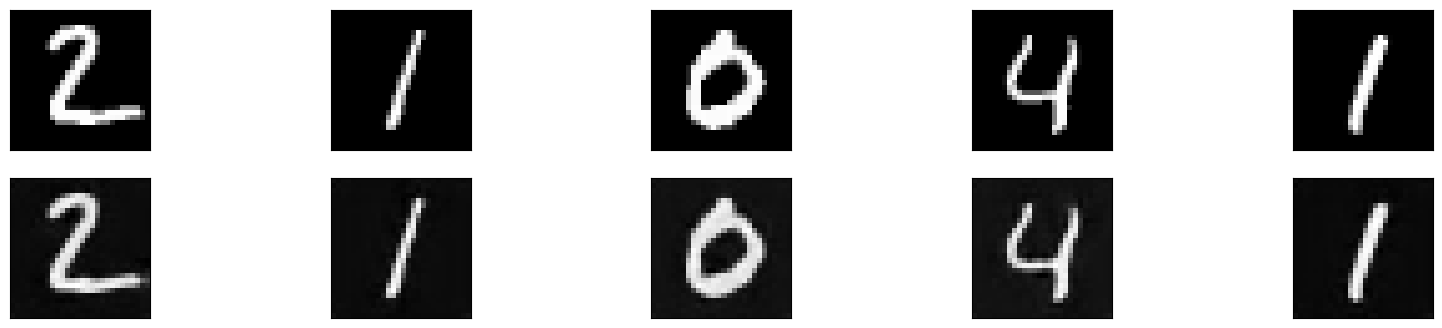

In [102]:
n = 5
plt.figure(figsize=(20, 4))
for i in range(1, n + 1, 1):
    # original
    ax = plt.subplot(2, n, i)
    plt.imshow(X_test[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    # reconstructed
    ax = plt.subplot(2, n, i + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

label 7에 속하는 X_test[0]의 이미지의 CFP를 구하고자 한다.

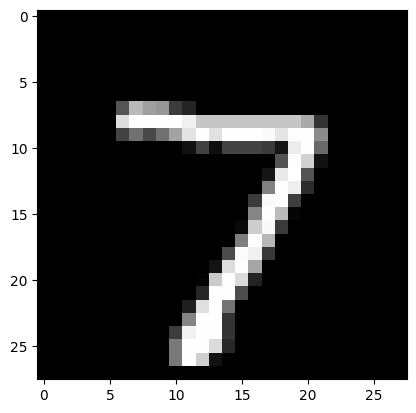

In [104]:
X_sample = X_test[0].reshape((1, ) + X_test[0].shape)
plt.imshow(X_sample.reshape(28, 28))

autoencoder 손실과 x_proto 손실이 CFP를 구하는 데 추가되므로 다음과 같이 autoencoder 손실의 가중치 gamma와 x_proto 손실의 가중치 theta 값을 각각 100으로 부여하고 있다.

In [112]:
cfp_config ={
    'shape': (1, ) + X_train.shape[1:],
    'gamma': 100.0,
    'theta': 100.0,
    'c_init': 1.0,
    'c_steps': 2,
    'max_iterations': 1000,
    'feature_range': (X_train.min(), X_train.max()),
    'ae_model': ae
}

`cf.explain()`의 입력 옵션 `k`를 None으로 부여하면 x_proto는 설명 변수의 평균으로 구해진다.

In [113]:
cf = CounterfactualProto(cnn, **cfp_config)
start_time = time()
cf.fit(X_train)
print('Time to find prototypes each class: {:.3f} sec'.format(time() - start_time))
start_time = time()
explanation = cf.explain(X_sample)
print('explanation took {:.3f}'.format(time() - start_time))

Time to find prototypes each class: 2.175 sec


2025-03-14 17:07:14.562208: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inloss_attack_5/CNN_1/dropout_21/cond/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


explanation took 11.737


Counterfactual prediction: 3
Closest prototype class: None


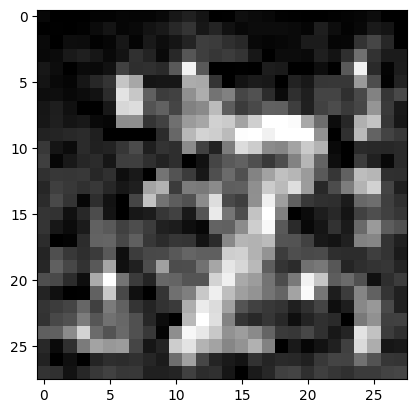

In [114]:
print(f"Counterfactual prediction: {explanation.cf['class']}")
print(f"Closest prototype class: {explanation.id_proto}")
plt.imshow(explanation.cf['X'].reshape(28, 28))

다음은 `.data['all']`을 이용하여 이미지 7에서 CFP의 ?????? 로 변해가는 과정을 보여준다.

/tmp/ipykernel_1370/134906550.py:5: DeprecationWarning: The Explanation object is not a dictionary anymore and accessing elements should be done via attribute access. Accessing via item will stop working in a future version.
  plt.imshow(explanation['all'][i][0].reshape(28, 28))


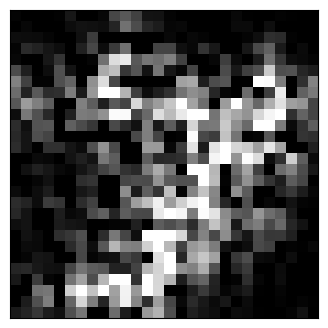

In [121]:
n = len(explanation.data['all'])
plt.figure(figsize=(20, 4))
for i in range(n):
    ax = plt.subplot(1, n + 1, n + 1)
    plt.imshow(explanation['all'][i][0].reshape(28, 28))
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

In [122]:
cf = CounterfactualProto(cnn, **cfp_config)
cf.fit(X_train)
explanation_k1 = cf.explain(X_sample, k=1, k_type='mean')
explanation_k20 = cf.explain(X_sample, k=1, k_type='mean')

2025-03-14 17:10:39.232032: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inloss_attack_6/CNN_1/dropout_21/cond/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


다음은 k가 1인 경우의 CFP의 예측 label, x_proto의 label 그리고 CFP의 label 이미지를 출력한다.

Counterfactual prediction: 2
Closest prototype class: None


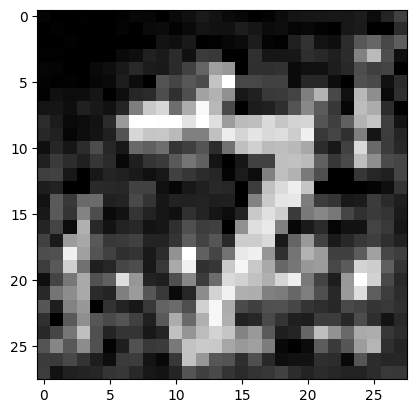

In [123]:
print(f"Counterfactual prediction: {explanation_k1.cf['class']}")
print(f"Closest prototype class: {explanation_k1.id_proto}")
plt.imshow(explanation_k1.cf['X'].reshape(28, 28))

Counterfactual prediction: 9
Closest prototype class: None


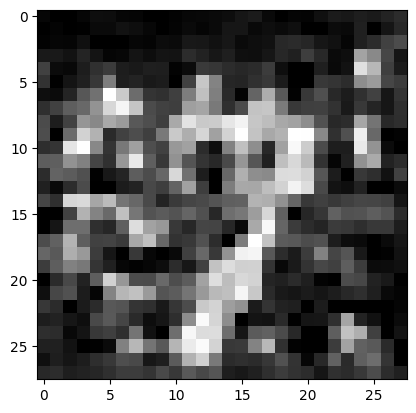

In [124]:
print(f"Counterfactual prediction: {explanation_k20.cf['class']}")
print(f"Closest prototype class: {explanation_k20.id_proto}")
plt.imshow(explanation_k20.cf['X'].reshape(28, 28))